## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Loading and Exploring Dataset

In [2]:
Data = pd.read_csv("Loan_Modelling.csv")
Data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [3]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [4]:
Data.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

## There is no missing values in the data

In [5]:
Data.shape

(5000, 14)

In [6]:
Data.describe()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


## Observations
 - Experiance cannot be negative 
 - All the columns are in integers, no string values
 - Categorical columns: Education, Personal_Loan, Securities_Account, CD_Account, Online, CreditCard
 - Numerical columns: ID, Age, Experience, Income, ZIP_code, Family, CCAvg, Mortgage

## Finding patterns in data

## Univariate analysis

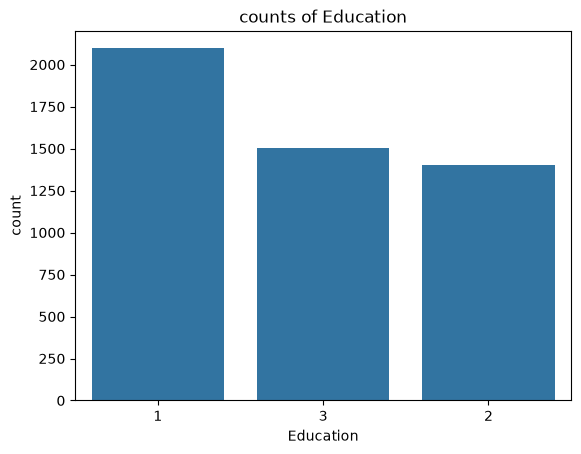

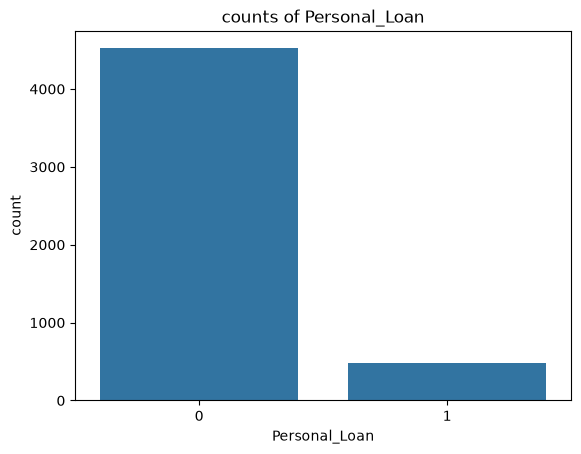

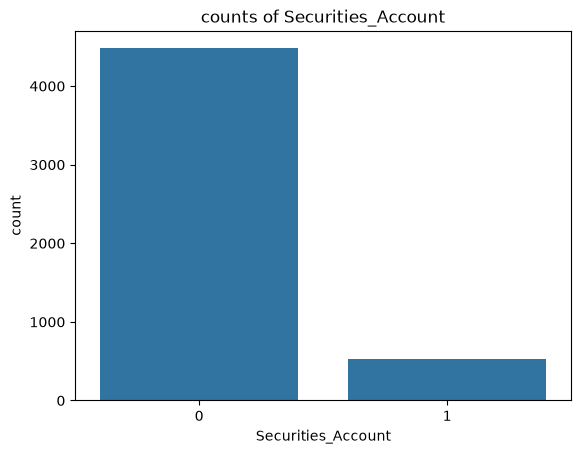

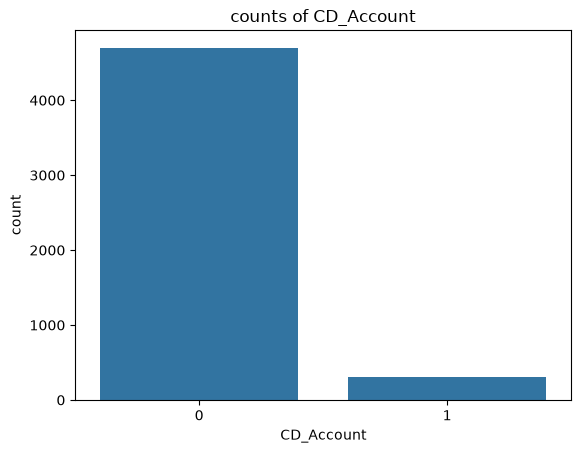

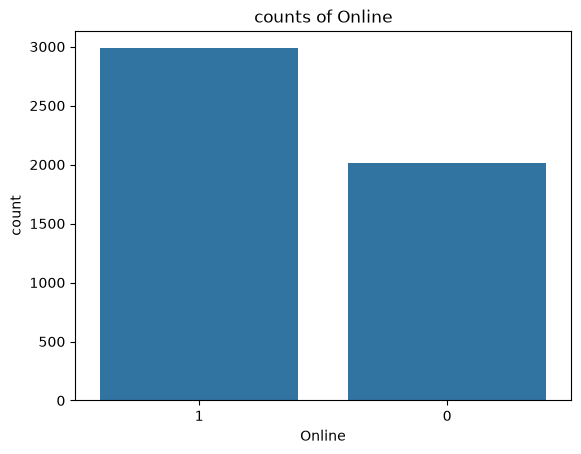

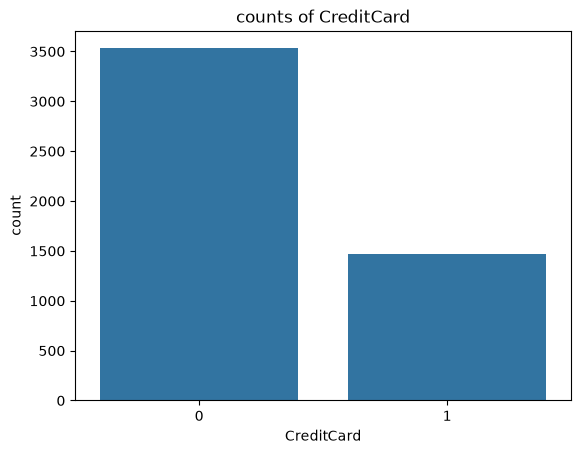

In [7]:
# For categorical distribution
for c in ["Education", "Personal_Loan", "Securities_Account", "CD_Account", "Online", "CreditCard"]:
    sns.countplot(x=c, data=Data, order=Data[c].value_counts().index)
    plt.title(f"counts of {c}")
    plt.show()


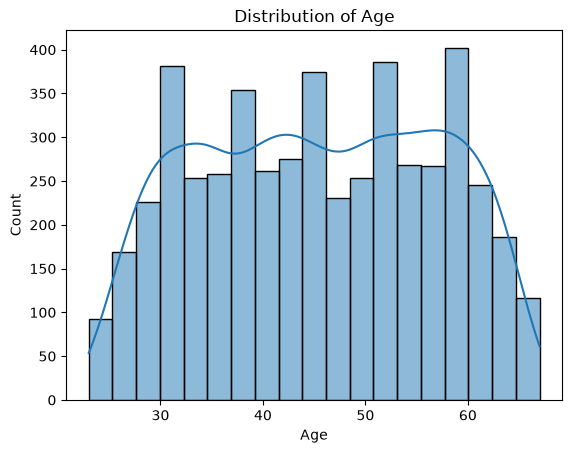

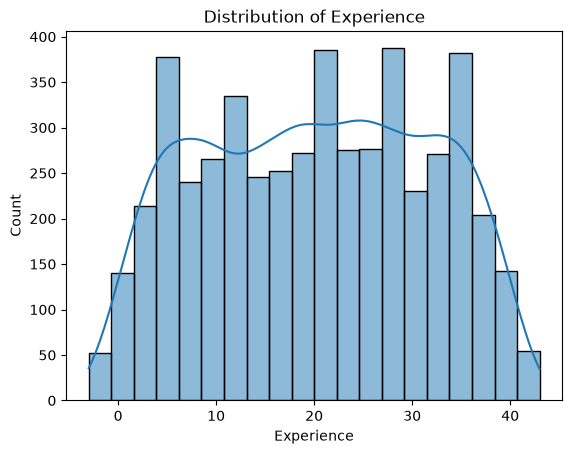

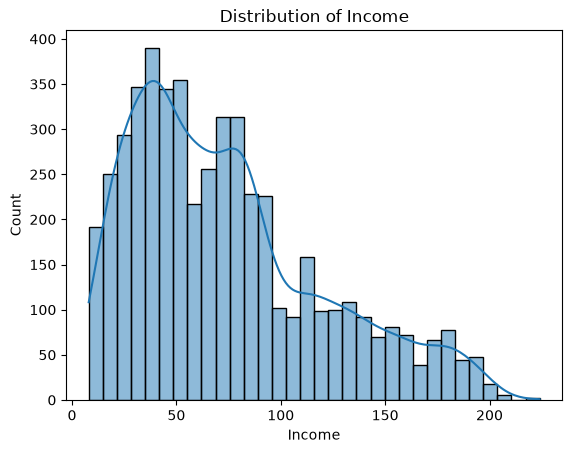

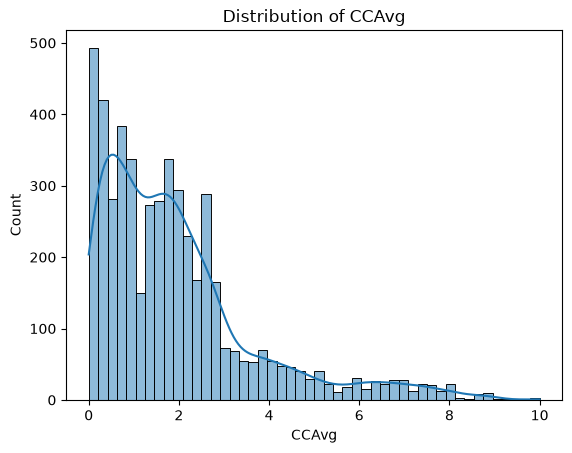

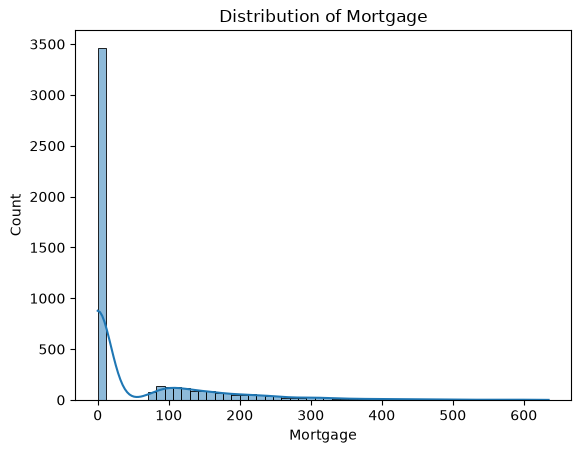

In [8]:
#For numerical Distribution
for x in ["Age", "Experience", "Income", "CCAvg", "Mortgage"]:
    sns.histplot(Data[x], kde=True)
    plt.title(f"Distribution of {x}")
    plt.show()

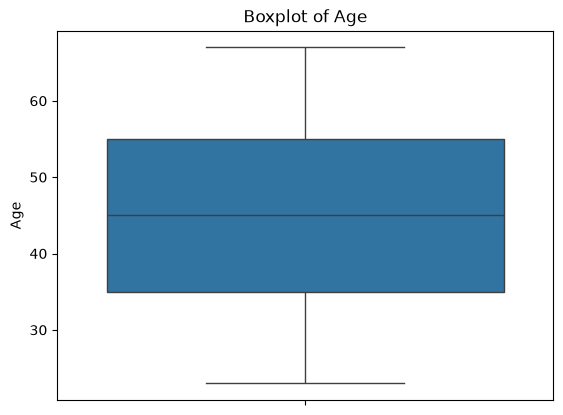

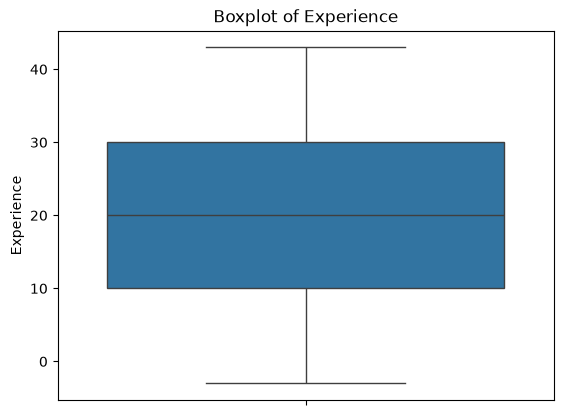

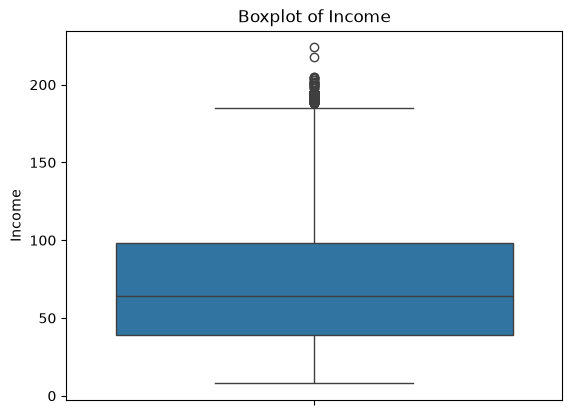

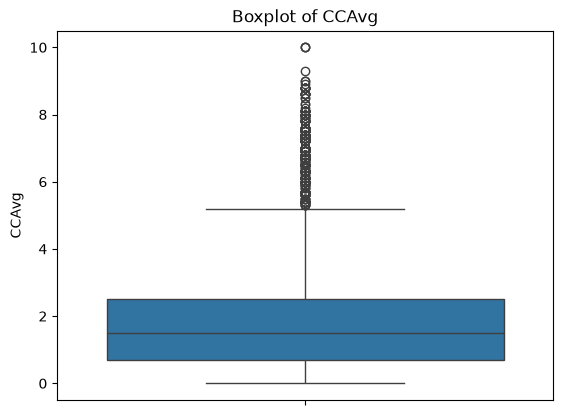

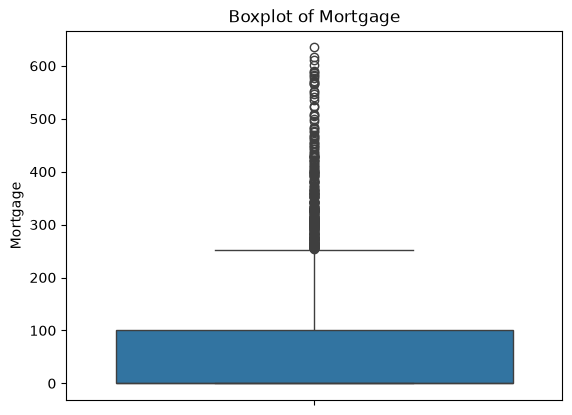

In [9]:
for c in ["Age", "Experience", "Income", "CCAvg", "Mortgage"]:
    plt.figure()
    sns.boxplot(y=Data[c])
    plt.title(f"Boxplot of {c}")
    plt.show()

## Bivariate analysis

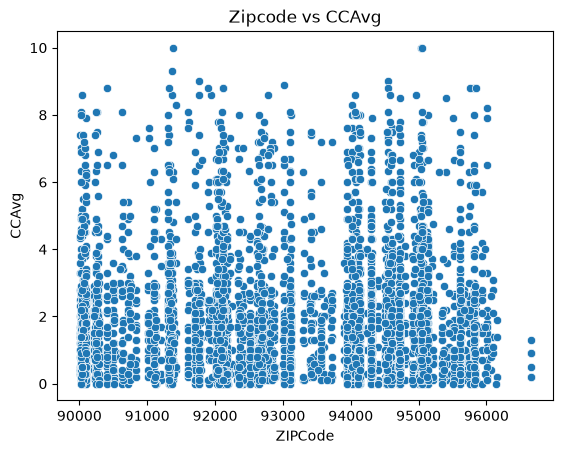

In [10]:
sns.scatterplot(x = "ZIPCode", y= "CCAvg", data=Data )
plt.title("Zipcode vs CCAvg")
plt.show()

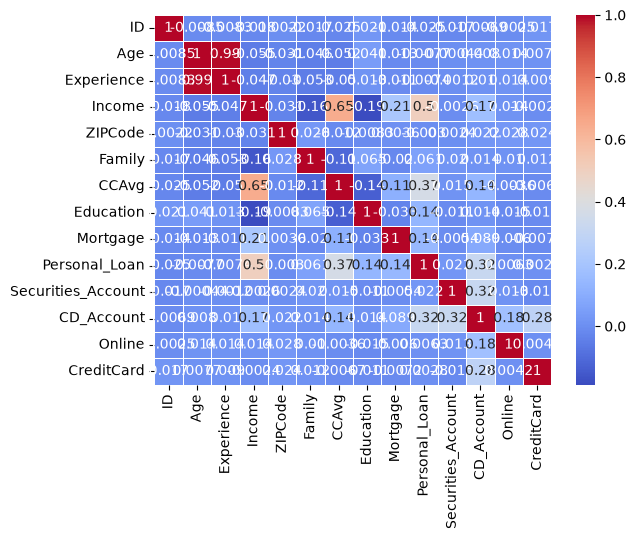

In [11]:
corr = Data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.show()

# From boxplots Income and mortgage features have outliers 

In [12]:
df = Data.copy()


In [13]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

low, high = iqr_bounds(df["Income"])
low2, high2 = iqr_bounds(df["Mortgage"])


print(f"Income outlier bounds: {low:,.0f} to {high:,.0f}")
print("Income outliers:", ((df["Income"] < low) | (df["Income"] > high)).sum())

print(f"Mortgage outlier bounds: {low2:,.0f} to {high2:,.0f}")
print("Mortgage outliers:", ((df["Income"] < low) | (df["Income"] > high)).sum())

Income outlier bounds: -50 to 186
Income outliers: 96
Mortgage outlier bounds: -152 to 252
Mortgage outliers: 96


In [14]:
df[(df["Income"] < low) | (df["Income"] > high)][
    ["ID", "Age", "Experience", "Mortgage"]]

,ID,Age,Experience,Mortgage
18,19,46,21,0
47,48,37,12,211
53,54,50,26,240
59,60,31,5,455
303,304,49,25,617
...,...,...,...,...
4659,4660,28,4,0
4670,4671,52,26,0
4895,4896,45,20,0
4981,4982,34,9,122


In [15]:
z = (df["Income"] - df["Income"].mean() )/ df["Income"].std()
print(" Income values for |z| > 3:\n ", df.loc[z.abs() > 3, "Income"].to_string())

z = (df["Mortgage"] - df["Mortgage"].mean() )/ df["Mortgage"].std()
print(" Mortgage values for |z| > 3:\n ", df.loc[z.abs() > 3, "Mortgage"].to_string())

 Income values for |z| > 3:
  3896    224
4993    218
 Mortgage values for |z| > 3:
  42      412
59      455
119     366
288     391
303     617
327     402
338     392
354     419
365     466
459     458
473     547
479     470
528     378
570     485
679     364
684     449
782     587
888     372
952     524
1023    366
1111    442
1162    394
1167    475
1273    437
1277    428
1288    366
1303    382
1304    397
1328    380
1359    433
1372    483
1623    455
1674    421
1716    565
1736    394
1783    601
1789    567
1875    389
1889    372
1937    589
1970    397
2027    380
2041    535
2076    398
2217    446
2319    422
2382    428
2394    505
2422    400
2443    422
2541    569
2590    374
2653    408
2668    406
2687    452
2714    432
2753    477
2768    396
2769    582
2776    380
2812    467
2841    565
2934    635
2942    385
2946    437
2956    522
2989    496
3012    415
3020    392
3021    461
3065    368
3209    373
3304    383
3357    408
3373    442
3411    427
34

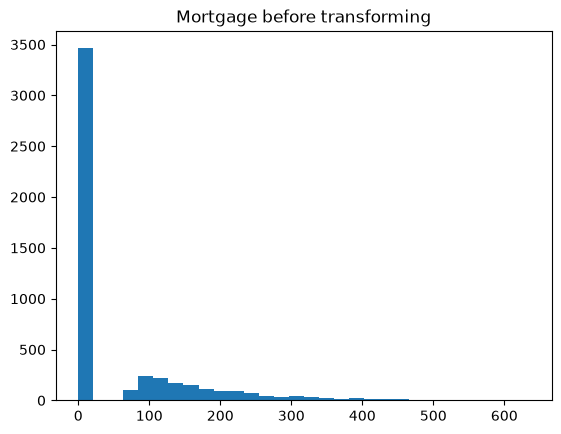

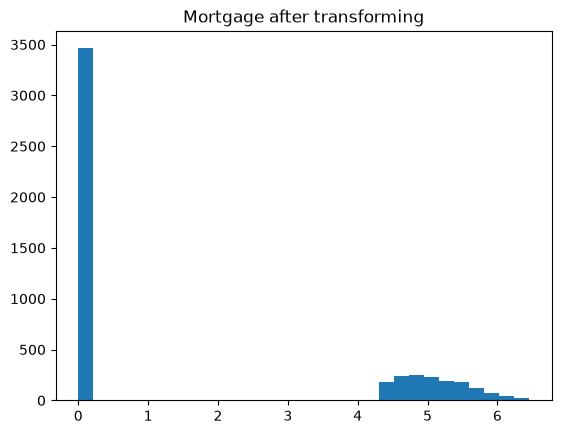

In [16]:
#before transformation
plt.hist(df["Mortgage"], bins=30)
plt.title("Mortgage before transforming")
plt.show()

#after transforming
plt.hist(np.log1p(df["Mortgage"].dropna()), bins=30)
plt.title("Mortgage after transforming")
plt.show()

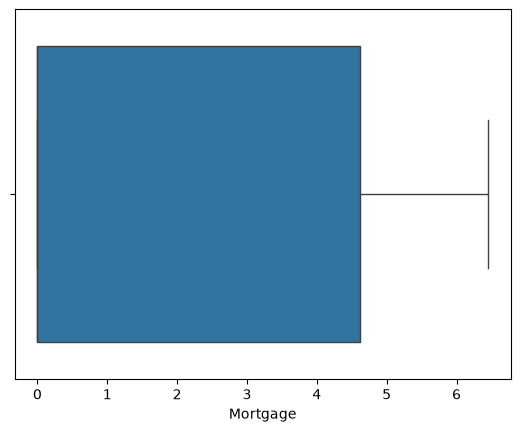

In [17]:
sns.boxplot(x=np.log1p(df["Mortgage"]))
plt.show()

# Feature scaling Income, mortgage to treat outliers

In [21]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

num_columns = ["Mortgage", "Income"]

standard = StandardScaler().fit_transform(df[num_columns])

print("StandardScaler -> mean ~0, std ~1:")
print(pd.DataFrame(standard, columns=num_columns).describe().loc[["mean", "std"]].round(2))


StandardScaler -> mean ~0, std ~1:
      Mortgage  Income
mean      -0.0     0.0
std        1.0     1.0


## Feature scaling

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["CCAvg", "ID"])
y = df["CCAvg"]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
print("Train:", x_train.shape, " Test:", x_test.shape)

Train: (3500, 12)  Test: (1500, 12)


## handling zip codes 
## Target encoding

In [23]:
import category_encoders as ce
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

encoder = ce.TargetEncoder(cols=["ZIPCode"])

#Fit the encoder on the TRAINING data and transform it
X_train_encoded = encoder.fit_transform(x_train, y_train)

# Transform the TESTING data using the learned training mappings
X_test_encoded = encoder.transform(x_test)

# Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train_encoded, y_train)

# Make Predictions
y_pred = model.predict(X_test_encoded)

# Evaluate Model Performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate Adjusted R2
n = len(y_test)  # Number of samples
p = X_test_encoded.shape[1]  # Number of predictors
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Print evaluation results
print("--- Model Evaluation Metrics ---")
print(f"R2 Score:         {r2:.4f}")
print(f"Adjusted R2:      {adj_r2:.4f}")
print(f"MAE:              ${mae:.2f}")
print(f"RMSE:             ${rmse:.2f}")

# Look at how the encoded features look now
print("\n--- Snippet of Transformed Training Features ---")
print(X_train_encoded.head())

--- Model Evaluation Metrics ---
R2 Score:         0.3690
Adjusted R2:      0.3639
MAE:              $1.03
RMSE:             $1.41

--- Snippet of Transformed Training Features ---
      Age  Experience  Income   ZIPCode  Family  Education  Mortgage  \
1334   47          22      35  1.799567       2          1         0   
4768   38          14      39  1.789404       1          2         0   
65     59          35     131  2.145787       1          1         0   
177    29           3      65  1.821180       4          2       244   
4489   39          13      21  1.851774       3          2         0   

      Personal_Loan  Securities_Account  CD_Account  Online  CreditCard  
1334              0                   0           0       1           0  
4768              0                   0           0       1           0  
65                0                   0           0       1           1  
177               0                   0           0       0           0  
4489            